Загрузка библиотек

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Считываем данные и выведем состав и названия полей

In [8]:
x = pd.read_csv('https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML1.1%20linear%20regression/data/x.csv')
y = pd.read_csv('https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML1.1%20linear%20regression/data/y.csv')
x.head()

,Unnamed: 0,0
0,0,1.462108
1,1,1.133769
2,2,-2.301539
3,3,1.744812
4,4,0.042214


Форматирование данных

In [9]:
x = pd.read_csv('https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML1.1%20linear%20regression/data/x.csv', index_col=0)['0']
y = pd.read_csv('https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML1.1%20linear%20regression/data/y.csv', index_col=0)['0']
x.head()

0    1.462108
1    1.133769
2   -2.301539
3    1.744812
4    0.042214
Name: 0, dtype: float64

Построение графика линейной зависимости

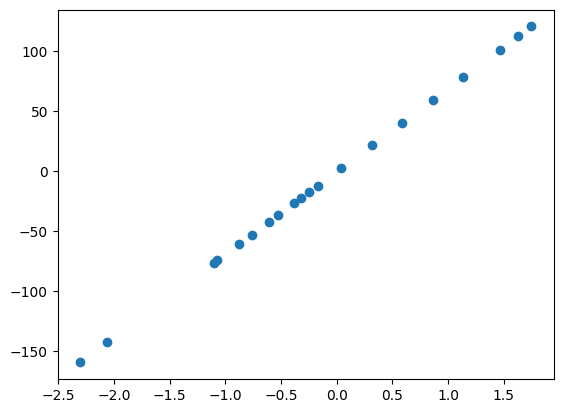

In [10]:
plt.figure()
plt.scatter(x, y)
plt.show()

Построение класса,который будет реализовывать метод парной линейной регрессии:

In [12]:
class Model(object):
    """Модель парной линейной регрессии"""
    def __init__(self):
        self.b0 = 0
        self.b1 = 0
    def predict(self, x):
        return self.b0 + self.b1 * x
    def error(self, X, Y):    
        return sum((self.predict(X) - Y)**2) / (2 * len(X))
    def fit(self, X, Y):  
        alpha = 0.1
        dJ0 = sum(self.predict(X) - Y) /len(X)
        dJ1 = sum((self.predict(X) - Y) * X) /len(X)
        self.b0 -= alpha * dJ0
        self.b1 -= alpha * dJ1

Создадим объект регрессии

In [13]:
hyp = Model()
print(hyp.predict(0))
print(hyp.predict(100))
J = hyp.error(x, y)
print("initial error:", J)

0
0
initial error: 2937.6446095153397


Изобразим регрессию на графике

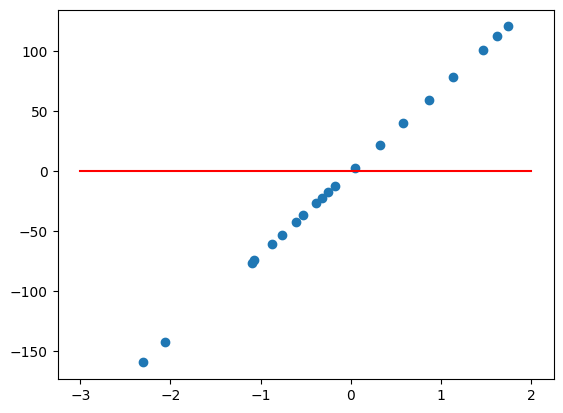

In [14]:
X0 = np.linspace(-3, 2, 100)
Y0 = hyp.predict(X0)
plt.figure()
plt.scatter(x, y)
plt.plot(X0, Y0, 'r')
plt.show()

Запуск градиентого спуска

In [15]:
hyp.fit(x, y)
J = hyp.error(x, y)
print("error after gradient descent:", J)

error after gradient descent: 2253.745680891855


График спуска

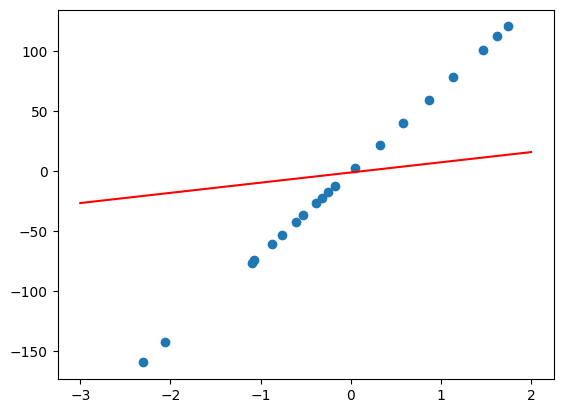

In [16]:
X0 = np.linspace(-3, 2, 100)
Y0 = hyp.predict(X0)
plt.figure()
plt.scatter(x, y)
plt.plot(X0, Y0, 'r')
plt.show()

Модифицируем класс, чтобы он запускал градиентный спуск определенное количество циклов

In [17]:
class Model(object):
    """Модель парной линейной регрессии"""
    def __init__(self):
        self.b0 = 0
        self.b1 = 0
    def predict(self, X):
        return self.b0 + self.b1 * X
    def error(self, X, Y):
        return sum(((self.predict(X) - Y)**2) / (2 * len(X)))
    def fit(self, X, Y, alpha=0.001, accuracy=0.01, max_steps=5000):
        steps, errors = [], []
        step = 0        
        for _ in range(10000):
            dJ0 = sum(self.predict(X) - Y) /len(X)
            dJ1 = sum((self.predict(X) - Y) * X) /len(X)
            self.b0 -= alpha * dJ0
            self.b1 -= alpha * dJ1    
            new_err = hyp.error(X, Y)
            step += 1            
            steps.append(step)
            errors.append(new_err)
        return steps, errors

Запустим градиентный спуск еще раз

In [18]:
hyp = Model()
steps, errors = hyp.fit(x, y)
J = hyp.error(x, y)
print("error after gradient descent:", J)

error after gradient descent: 2.7769753060572152e-06


Еще раз выведем график

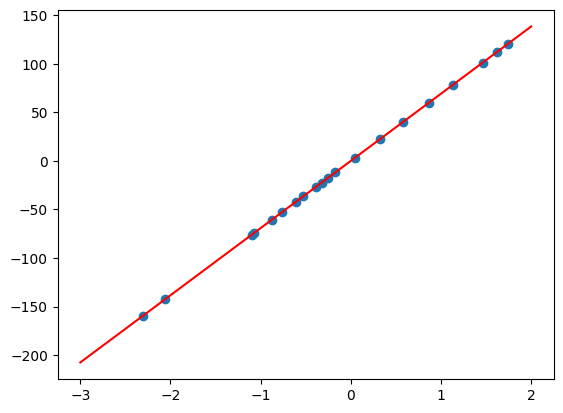

In [19]:
X0 = np.linspace(-3, 2, 100)
Y0 = hyp.predict(X0)
plt.figure()
plt.scatter(x, y)
plt.plot(X0, Y0, 'r')
plt.show()

График изменения ошибки регрессии со временем 

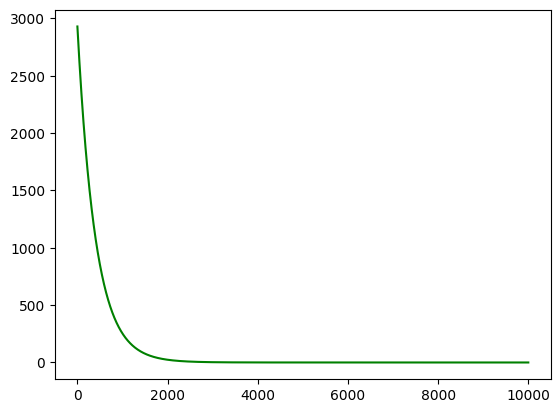

In [20]:
plt.figure()
plt.plot(steps, errors, 'g')
plt.show()

# Задания для самостоятельног овыполнения.

1. Проверьте работу модели с разными начальными значениями параметров. Убедитесь, что модель всегда сходится к оптимуму.

Модифицируем класс чтобы можно было задавать значения параметров из вне

In [22]:
class Model(object):
    """Модель парной линейной регрессии"""
    def __init__(self, b0 = 0, b1 = 0):
        self.b0 = b0
        self.b1 = b1
    def predict(self, X):
        return self.b0 + self.b1 * X
    def error(self, X, Y):
        return sum(((self.predict(X) - Y)**2) / (2 * len(X)))
    def fit(self, X, Y, alpha=0.001, accuracy=0.01, max_steps=5000):
        steps, errors = [], []
        step = 0        
        for _ in range(max_steps):
            dJ0 = sum(self.predict(X) - Y) /len(X)
            dJ1 = sum((self.predict(X) - Y) * X) /len(X)
            self.b0 -= alpha * dJ0
            self.b1 -= alpha * dJ1    
            new_err = hyp.error(X, Y)
            step += 1            
            steps.append(step)
            errors.append(new_err)
        return steps, errors

error after gradient descent: 0.029007729872320673


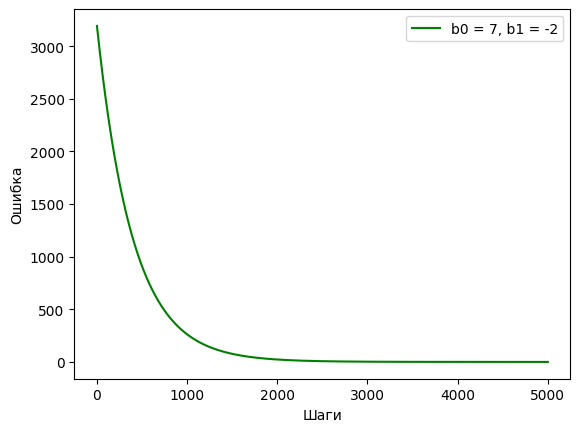

error after gradient descent: 0.03937321303112905


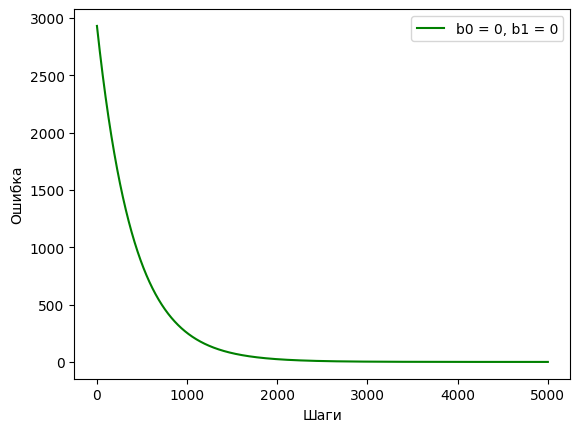

error after gradient descent: 0.03632269468793789


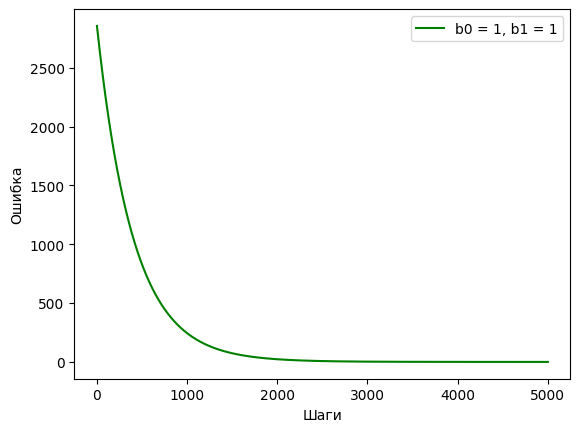

error after gradient descent: 0.011476011490787787


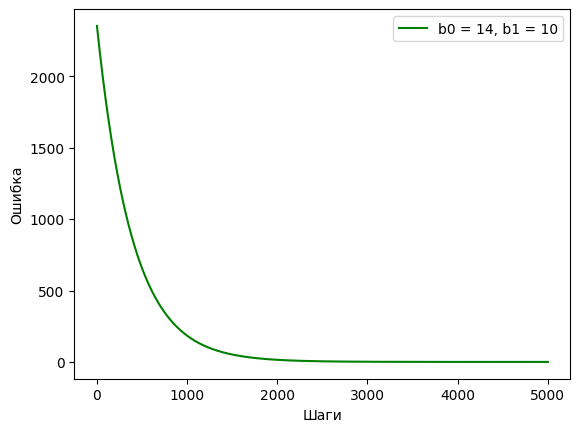

In [24]:
initial_params = [
    (7, -2),
    (0, 0),  
    (1, 1),  
    (14, 10), 
]

# Проверка для каждой комбинации начальных значений
for b0, b1 in initial_params:
    hyp = Model(b0, b1)
    steps, errors = hyp.fit(x, y, alpha=0.001)
    J = hyp.error(x, y)
    print("error after gradient descent:", J)
    # Построение графика
    plt.figure()
    plt.plot(steps, errors, 'g', label=f'b0 = {b0}, b1 = {b1}')
    plt.xlabel('Шаги')
    plt.ylabel('Ошибка')
    plt.legend()
    plt.show()

2. Проверьте работу модели с другими значениями скорости обучения. Найдите значение, при котором градиентный спуск расходится.

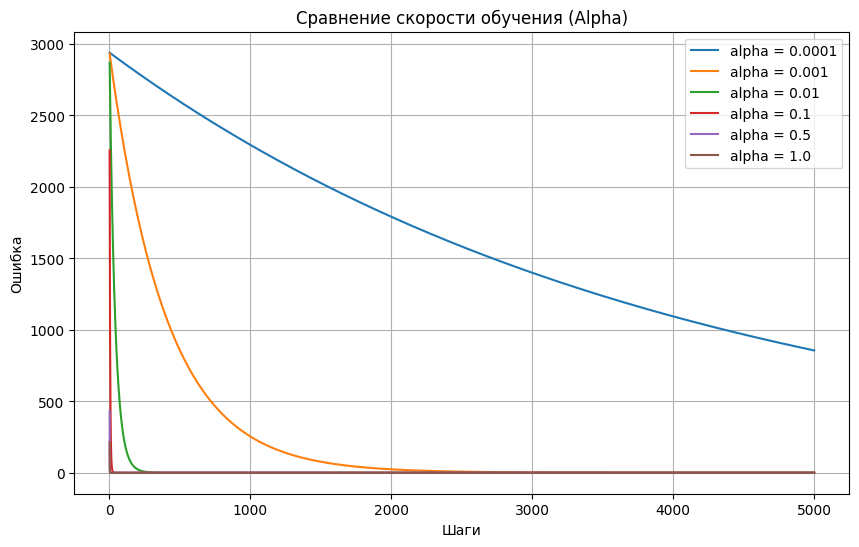

In [28]:
# Значения α для проверки
alphas = [0.0001, 0.001, 0.01, 0.1, 0.5, 1.0]

# Проверка для каждого α
plt.figure(figsize=(10, 6)) # Создаем ОДНУ фигуру до цикла

for alpha in alphas:
    hyp = Model(0, 0)
    steps, errors = hyp.fit(x, y, alpha=alpha)
    
    # Рисуем линию на текущей активной фигуре (не создаем новую!)
    plt.plot(steps, errors, label=f'alpha = {alpha}')

plt.xlabel('Шаги')
plt.ylabel('Ошибка')
plt.title('Сравнение скорости обучения (Alpha)')
plt.legend()
plt.grid(True) # Сетка для удобства
plt.show() # Показываем всё разом в конце

3.Модифицируйте код модели таким образом, чтобы он корректно работал как с Series, так и с DataFrame. При этом, конечно, датафрейм не должен содержать "лишних" столбцов. <br>
4.Модифицируйте алгоритм градиентного спука таким образом, чтобы он останавливаля, если ошибка перестает снижаться. Для этого сравнивайте, на сколько понизилась ошибка на каждом шаге и если это снижение меньше некоторой заранее заданной очень маленькой величины - выходите из цикла. Эту величину можно взять одну миллионную, например.<br>
5.Убедитесь, что алгоритм градиентного спуска завершается всегда - либо если ошибка перестает существенно меняться, либо при достижении максимального количества шагов.<br>
6.Реализуйте механизм адаптивной скорости обучения. Чтобы не задавать вручную параметр alpha можно отслеживать, увеличивается ли ошибка после первого шага градиентного спуска. В начале задаем скорость обучения близкой к 1. Если ошибка после одного шага увеличивается - скорость обучения надо уменьшить (например, в 2 раза). Если не увеличивается - скорость обучения можно не трогать. Еще подумайте, как после уменьшения скорости перезапускать градиентный спуск заново.<br>
7.Добавьте к классу модели метод рисования графиков. Сделайте так, чтобы он был независим от масштаба переданных данных.<br>

In [36]:
class Model(object):
    def __init__(self, b0=0, b1=0):
        self.b0 = b0
        self.b1 = b1

    # --- ПУНКТ 3: Вспомогательный метод для обработки Series и DataFrame ---
    def _prepare_input(self, X, Y=None):
        """
        Преобразует входные данные в numpy-массивы.
        Гарантирует работу и с Series, и с DataFrame.
        """
        # Обработка X
        if isinstance(X, pd.DataFrame):
            # Если DataFrame, берем первый столбец (удаляем "лишние", если их больше одного)
            # Или можно оставить как есть, если модель поддерживает многомерность, 
            # но в формуле b0 + b1*X подразумевается 1D.
            if X.shape[1] > 1:
                print("Warning: DataFrame has multiple columns. Using the first one.")
            X = X.iloc[:, 0].values 
        elif isinstance(X, pd.Series):
            X = X.values
        else:
            X = np.asarray(X).flatten()

        # Обработка Y (если передан)
        if Y is not None:
            if isinstance(Y, pd.DataFrame):
                Y = Y.iloc[:, 0].values
            elif isinstance(Y, pd.Series):
                Y = Y.values
            else:
                Y = np.asarray(Y).flatten()
            return X, Y
        
        return X

    def predict(self, X):
        # Используем подготовку данных для корректной работы с pandas
        X = self._prepare_input(X)
        return self.b0 + self.b1 * X

    def error(self, X, Y):
        # Используем подготовку данных
        X, Y = self._prepare_input(X, Y)
        # MSE (Mean Squared Error)
        return np.sum((self.predict(X) - Y) ** 2) / (2 * len(X))

    def fit(self, X, Y, alpha=0.001, accuracy=0.01, max_steps=5000, min_delta=1e-6):
        # --- ПУНКТ 3: Гарантируем, что данные - numpy массивы ---
        X, Y = self._prepare_input(X, Y)

        steps, errors = [], []
        step = 0
        prev_err = None
        
        # Сохраняем начальные параметры, чтобы к ним возвращаться при неудаче
        # Но для адаптивности нам нужно помнить "последнее хорошее состояние"
        current_b0, current_b1 = self.b0, self.b1 

        while step < max_steps:
            # --- ПУНКТ 5: Гарантия завершения (цикл ограничен max_steps) ---
            
            # Считаем градиенты
            # Важно: используем текущие X, Y (уже numpy)
            predictions = self.b0 + self.b1 * X
            dJ0 = np.sum(predictions - Y) / len(X)
            dJ1 = np.sum((predictions - Y) * X) / len(X)
            
            # Делаем шаг
            self.b0 -= alpha * dJ0
            self.b1 -= alpha * dJ1
            
            new_err = self.error(X, Y)

            # --- ПУНКТ 6: Адаптивная скорость обучения ---
            if prev_err is not None and new_err > prev_err:
                # Если ошибка увеличилась:
                # 1. Уменьшаем скорость обучения (в 2 раза)
                alpha /= 2
                # 2. Возвращаем параметры к состоянию ДО этого шага
                self.b0, self.b1 = current_b0, current_b1
                # 3. Перезапускаем цикл (пробуем сделать шаг с новым alpha)
                continue

            # Если мы здесь, значит шаг успешный (ошибка уменьшилась или это первый шаг)
            # Запоминаем текущие параметры как "хорошие"
            current_b0, current_b1 = self.b0, self.b1

            # --- ПУНКТ 4: Остановка, если ошибка перестает снижаться ---
            if prev_err is not None and abs(prev_err - new_err) < min_delta:
                print('Ended by insignificant error change')
                # Сохраняем шаг и ошибку перед выходом, чтобы график был полным
                step += 1
                steps.append(step)
                errors.append(new_err)
                break
                
            prev_err = new_err
            step += 1
            steps.append(step)
            errors.append(new_err)
            
        else:
            # Этот блок сработает, если цикл завершился по условию step < max_steps (не по break)
            print('Ended by finishing max_steps')

        return steps, errors

    # --- ПУНКТ 7: Метод рисования графиков, независимый от масштаба ---
    def plot(self, steps, errors):
        plt.figure(figsize=(10, 5))
        
        # Чтобы график был независим от масштаба данных (например, если ошибка 1000 или 0.001),
        # можно нормализовать ошибку относительно начальной ошибки.
        # Тогда график всегда будет показывать "долю оставшейся ошибки" от 1 до 0.
        if len(errors) > 0 and errors[0] != 0:
            errors_normalized = [e / errors[0] for e in errors]
            plt.plot(steps, errors_normalized, label='Нормализованная ошибка (Начальаня ошибка / Текущая ошибка)')
            plt.ylabel('Нормализованная ошибка')
        else:
            plt.plot(steps, errors, label='Ошибка')
            plt.ylabel('Ошибка')
            
        plt.xlabel('Шаги')
        plt.title('График обучения')
        plt.legend()
        plt.grid(True)
        plt.show()

Ended by insignificant error change
Found coefficients: b0=4.70, b1=2.03


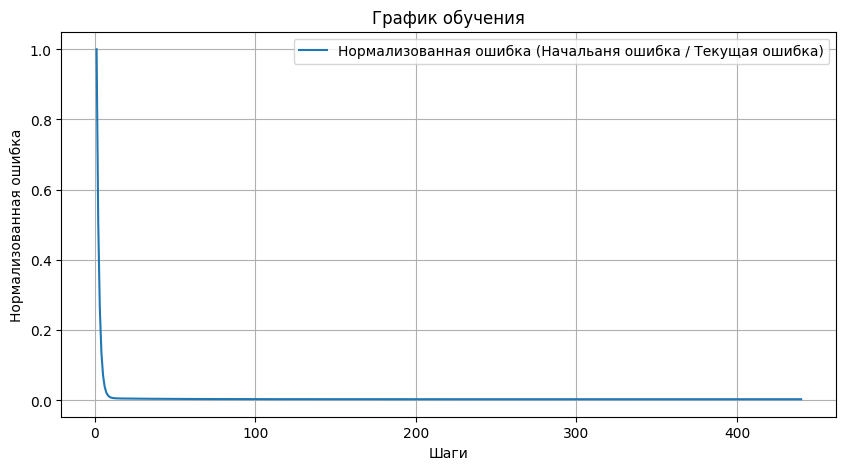

In [37]:
x_data = np.linspace(0, 10, 100)
y_data = 2 * x_data + 5 + np.random.randn(100) * 2 # y = 2x + 5 + noise

# Тестируем ПУНКТ 3: Передаем DataFrame
df_X = pd.DataFrame({'feature': x_data})
series_Y = pd.Series(y_data)

model = Model()

# Тестируем ПУНКТ 6: Задаем большой alpha, чтобы сработала адаптивность
steps, errors = model.fit(df_X, series_Y, alpha=0.1, max_steps=5000) 

print(f"Found coefficients: b0={model.b0:.2f}, b1={model.b1:.2f}")

# Тестируем ПУНКТ 7
model.plot(steps, errors)